In [78]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#Install and Load spaCy
!pip install spacy


#Load spaCy
import spacy
nlp = spacy.load("en_core_web_sm")






#Install kagglehu
!pip install -q kagglehub

#download the dataset from kaggle
path = kagglehub.dataset_download("lburleigh/asap-2-0")

print("Dataset downloaded to:")
print(path)

#show the files in the kaggle asap_2.0 dataset
os.listdir(path)

#loading the dataset to google colab
df = pd.read_csv(os.path.join(path, "ASAP2_train_sourcetexts.csv"))
print(df.head())
print()
print(df.info())
print()
print(df.describe())
print()
print(df.columns)
print()
print(df.isnull().sum())
print()
print(df.duplicated().sum())




Using Colab cache for faster access to the 'asap-2-0' dataset.
Dataset downloaded to:
/kaggle/input/asap-2-0
               essay_id  score  \
0  AAAVUP14319000159574      4   
1  AAAVUP14319000159542      2   
2  AAAVUP14319000159461      3   
3  AAAVUP14319000159420      2   
4  AAAVUP14319000159419      2   

                                           full_text  \
0  The author suggests that studying Venus is wor...   
1  NASA is fighting to be alble to to go to Venus...   
2  "The Evening Star", is one of the brightest po...   
3  The author supports this idea because from rea...   
4  How the author supports this idea is that he s...   

                                          assignment      prompt_name  \
0  In "The Challenge of Exploring Venus," the aut...  Exploring Venus   
1  In "The Challenge of Exploring Venus," the aut...  Exploring Venus   
2  In "The Challenge of Exploring Venus," the aut...  Exploring Venus   
3  In "The Challenge of Exploring Venus," the aut...  Exp

In [79]:
columns_to_keep = [
    "essay_id",
    "score",
    "full_text",
    "assignment",
    "prompt_name"
]

df = df[columns_to_keep]

print(df.head())
print()
print(df.info())
print()
print(df.describe())
print()
print(df.columns)
print()
print(df.isnull().sum())
print()
print(df.duplicated().sum())


df["full_text"] = df["full_text"].str.strip()
df["assignment"] = df["assignment"].str.strip()
df["prompt_name"] = df["prompt_name"].str.strip()

(df["full_text"] == "").sum()
df["score"].value_counts().sort_index()



               essay_id  score  \
0  AAAVUP14319000159574      4   
1  AAAVUP14319000159542      2   
2  AAAVUP14319000159461      3   
3  AAAVUP14319000159420      2   
4  AAAVUP14319000159419      2   

                                           full_text  \
0  The author suggests that studying Venus is wor...   
1  NASA is fighting to be alble to to go to Venus...   
2  "The Evening Star", is one of the brightest po...   
3  The author supports this idea because from rea...   
4  How the author supports this idea is that he s...   

                                          assignment      prompt_name  
0  In "The Challenge of Exploring Venus," the aut...  Exploring Venus  
1  In "The Challenge of Exploring Venus," the aut...  Exploring Venus  
2  In "The Challenge of Exploring Venus," the aut...  Exploring Venus  
3  In "The Challenge of Exploring Venus," the aut...  Exploring Venus  
4  In "The Challenge of Exploring Venus," the aut...  Exploring Venus  

<class 'pandas.core.frame

,count
score,
1,1751
2,6847
3,9021
4,5553
5,1356
6,200


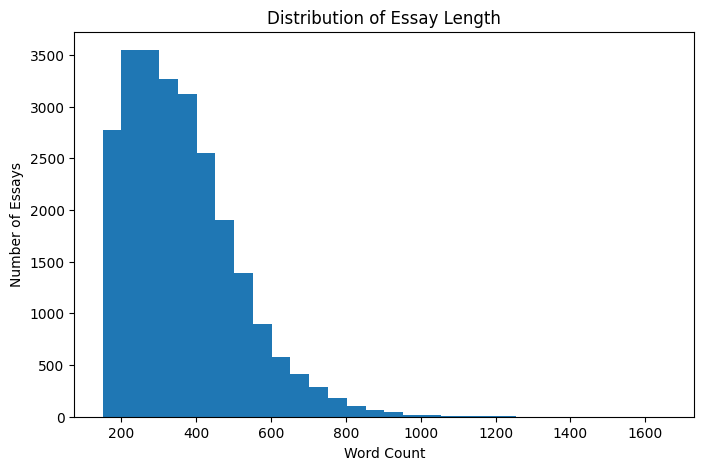

In [80]:
#Feature engineering
df["word_count"] = df["full_text"].apply(lambda x: len(x.split()))
df["word_count"].describe()


plt.figure(figsize=(8,5))
plt.hist(df["word_count"], bins=30)
plt.xlabel("Word Count")
plt.ylabel("Number of Essays")
plt.title("Distribution of Essay Length")
plt.show()

In [81]:
df[df["word_count"] < 20]

df.to_csv("cleaned_asap.csv", index=False)

In [82]:
import re
#Feature engineering
df["character_count"] = df["full_text"].apply(len)

df["sentence_count"] = df["full_text"].apply(lambda x: len(re.findall(r"[.!?]+", x)))

df["avg_sentence_length"] = (df["word_count"] / df["sentence_count"])

df["unique_words"] = df["full_text"].apply(lambda x: len(set(x.lower().split())))


In [83]:
X = df.drop(columns=["score"])
y = df["score"]


In [84]:

# Load the cleaned dataset
df = pd.read_csv("cleaned_asap.csv")

# Recreate features
df["character_count"] = df["full_text"].apply(len)
df["sentence_count"] = df["full_text"].apply(lambda x: len(re.findall(r"[.!?]+", x)))
df["sentence_count"] = df["sentence_count"].replace(0, 1)  # avoid division by zero
df["avg_sentence_length"] = df["word_count"] / df["sentence_count"]
df["unique_words"] = df["full_text"].apply(lambda x: len(set(x.lower().split())))


In [85]:
import re
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Start from the raw dataset
df = pd.read_csv(os.path.join(path, "ASAP2_train_sourcetexts.csv"))

# Feature engineering
df["word_count"] = df["full_text"].apply(lambda x: len(x.split()))

# Use word_count as predictor
X = df[["word_count"]]
y = df["score"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predictions
y_pred = lin_reg.predict(X_test)

# Evaluation
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

# Coefficients
### Interpret the Regression Coefficients

print("Intercept:", lin_reg.intercept_)
print("Coefficient for word_count:", lin_reg.coef_[0])



### Perform feature scaling / normalisation

from sklearn.preprocessing import StandardScaler

# Features Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)





MSE: 0.5481394448743183
MAE: 0.5601676454289176
R²: 0.48540647585883656
Intercept: 1.1444592527951005
Coefficient for word_count: 0.00496258469681277


In [ ]:
#Text Preprocessing for NLP
#Responsibilities
##Prepare essays for NLP.
#Perform tokenization.
#Sentence segmentation.
#Remove unnecessary whitespace.
#Prepare text for downstream analysis.
#Build reusable preprocessing functions.
#Deliverables
#Clean NLP-ready text.
#Tokenized essays.
#Sentence lists.


In [86]:
import pandas as pd

# Load dataset
df = pd.read_csv(os.path.join(path, "ASAP2_train_sourcetexts.csv"),  encoding="utf-8")


# Quick check
print(df[["essay_id", "full_text"]].head())



##Convert all text to lowercase
df["clean_text"] = df["full_text"].str.lower()


               essay_id                                          full_text
0  AAAVUP14319000159574  The author suggests that studying Venus is wor...
1  AAAVUP14319000159542  NASA is fighting to be alble to to go to Venus...
2  AAAVUP14319000159461  "The Evening Star", is one of the brightest po...
3  AAAVUP14319000159420  The author supports this idea because from rea...
4  AAAVUP14319000159419  How the author supports this idea is that he s...


In [87]:
from transformers import BertTokenizer

#TOKENIZATION

# Load pretrained tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Tokenize one essay
sample_text = df["clean_text"].iloc[0]
tokens = tokenizer.tokenize(sample_text)
print("Tokens:", tokens)

# Convert to IDs (needed for model input)
token_ids = tokenizer.encode(sample_text, add_special_tokens=True)
print("Token IDs:", token_ids)

# Store tokens for all essays
df["transformer_tokens"] = df["clean_text"].apply(lambda x: tokenizer.tokenize(x))


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (668 > 512). Running this sequence through the model will result in indexing errors


Tokens: ['the', 'author', 'suggests', 'that', 'studying', 'venus', 'is', 'worthy', 'enough', 'even', 'though', 'it', 'is', 'very', 'dangerous', '.', 'the', 'author', 'mentioned', 'that', 'on', 'the', 'planet', "'", 's', 'surface', ',', 'temperatures', 'average', 'over', '800', 'degrees', 'fa', '##hre', '##nh', '##eit', ',', 'and', 'the', 'atmospheric', 'pressure', 'is', '90', 'times', 'greater', 'than', 'what', 'we', 'experience', 'on', 'our', 'own', 'planet', '.', 'his', 'solution', 'to', 'survive', 'this', 'weather', 'that', 'is', 'dangerous', 'to', 'us', 'humans', 'is', 'to', 'allow', 'them', 'to', 'float', 'above', 'the', 'fray', '.', 'a', '"', 'b', '##lim', '##p', '-', 'like', '"', 'vehicle', 'hovering', '30', 'or', 'so', 'miles', 'would', 'help', 'avoid', 'the', 'un', '##fr', '##ien', '##dly', 'ground', 'conditions', '.', 'at', 'thirty', '-', 'plus', 'miles', 'above', 'the', 'surface', ',', 'temperatures', 'would', 'still', 'be', 'toast', '##y', 'at', 'around', '170', 'degrees', 

In [88]:
import spacy

# Create a lightweight spaCy pipeline
nlp = spacy.blank("en")          # minimal English pipeline
nlp.add_pipe("sentencizer")      # fast rule-based sentence splitter

# Convert essay texts into a list
texts = df["clean_text"].tolist()

# Process in batches using nlp.pipe
# batch_size can be tuned (50–200 usually works well)
docs = list(nlp.pipe(texts, batch_size=100))

# Extract sentences for each essay
df["sentences"] = [[sent.text.strip() for sent in doc.sents] for doc in docs]

# Quick check
print(df[["essay_id", "sentences"]].head())


for i, sents in enumerate(df["sentences"].head()):
    print(f"Essay {i}:")
    for sent in sents:
        print(" -", sent)



               essay_id                                          sentences
0  AAAVUP14319000159574  [the author suggests that studying venus is wo...
1  AAAVUP14319000159542  [nasa is fighting to be alble to to go to venu...
2  AAAVUP14319000159461  ["the evening star", is one of the brightest p...
3  AAAVUP14319000159420  [the author supports this idea because from re...
4  AAAVUP14319000159419  [how the author supports this idea is that he ...
Essay 0:
 - the author suggests that studying venus is worthy enough even though it is very dangerous.
 - the author mentioned that on the planet's surface, temperatures average over 800 degrees fahrenheit, and the atmospheric pressure is 90 times greater than what we experience on our own planet .
 - his solution to survive this weather that is dangerous to us humans is to allow them to float above the fray.
 - a "blimp-like" vehicle hovering 30 or so miles would help avoid the unfriendly ground conditions .
 - at thirty-plus miles above the s

In [89]:
import re

# Remove unnecessary whitespace
def clean_whitespace(text):
    # 1. Strip leading/trailing spaces
    text = text.strip()


    #  Replace multiple spaces/tabs/newlines with a single space
    text = re.sub(r"\s+", " ", text)


    # Normalize line breaks (convert \r, \r\n to \n)
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    return text

# Cleaning  dataset
df["clean_text"] = df["clean_text"].apply(clean_whitespace)



# Quick check
print(df[["essay_id", "clean_text"]].head())

for i, sents in enumerate(df["sentences"].head()):
    print(f"Essay {i}:")
    for sent in sents:
        print(" -", sent)


               essay_id                                         clean_text
0  AAAVUP14319000159574  the author suggests that studying venus is wor...
1  AAAVUP14319000159542  nasa is fighting to be alble to to go to venus...
2  AAAVUP14319000159461  "the evening star", is one of the brightest po...
3  AAAVUP14319000159420  the author supports this idea because from rea...
4  AAAVUP14319000159419  how the author supports this idea is that he s...
Essay 0:
 - the author suggests that studying venus is worthy enough even though it is very dangerous.
 - the author mentioned that on the planet's surface, temperatures average over 800 degrees fahrenheit, and the atmospheric pressure is 90 times greater than what we experience on our own planet .
 - his solution to survive this weather that is dangerous to us humans is to allow them to float above the fray.
 - a "blimp-like" vehicle hovering 30 or so miles would help avoid the unfriendly ground conditions .
 - at thirty-plus miles above the s

In [90]:
import re
import spacy

# Create spaCy pipeline (fast sentencizer only)
nlp = spacy.blank("en")
nlp.add_pipe("sentencizer")

# Define reusable preprocessing functions
def clean_text(text):
    # Lowercasing
    text = text.lower()
    # Strip leading/trailing spaces
    text = text.strip()
    # Replace multiple spaces/tabs/newlines with a single space
    text = re.sub(r"\s+", " ", text)
    # Normalize line breaks
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    return text

def tokenize_text(text):
    # Word-level tokenization using spaCy
    doc = nlp(text)
    return [token.text for token in doc]

def segment_sentences(text):
    # Sentence segmentation using spaCy sentencizer
    doc = nlp(text)
    return [sent.text.strip() for sent in doc.sents]

# Applying functions across all essays

df["clean_text"] = df["clean_text"].apply(clean_text)
df["tokens"] = df["clean_text"].apply(tokenize_text)
df["sentences"] = df["clean_text"].apply(segment_sentences)

# Quick check
print(df[["essay_id", "clean_text", "tokens", "sentences"]].head())


               essay_id                                         clean_text  \
0  AAAVUP14319000159574  the author suggests that studying venus is wor...   
1  AAAVUP14319000159542  nasa is fighting to be alble to to go to venus...   
2  AAAVUP14319000159461  "the evening star", is one of the brightest po...   
3  AAAVUP14319000159420  the author supports this idea because from rea...   
4  AAAVUP14319000159419  how the author supports this idea is that he s...   

                                              tokens  \
0  [the, author, suggests, that, studying, venus,...   
1  [nasa, is, fighting, to, be, alble, to, to, go...   
2  [", the, evening, star, ", ,, is, one, of, the...   
3  [the, author, supports, this, idea, because, f...   
4  [how, the, author, supports, this, idea, is, t...   

                                           sentences  
0  [the author suggests that studying venus is wo...  
1  [nasa is fighting to be alble to to go to venu...  
2  ["the evening star", is on